# Year-Holdout Cross-Validation Results

Every AUC-PR this project had reported before this notebook came from a
single, fixed train/val(/test) split. This notebook summarizes a
**leave-one-year-out cross-validation** run: 12 folds, each holding out one
full calendar year (2014-2025) as test and training an identical copy of
the project's best-known recipe (`TornadoUNet(base_channels=16)`,
alpha=0.25, 50 epochs, seed=0 -- the exact config behind
`models/unet/tornado_unet.pt`) on everything else. No architecture or
feature changes between folds -- the only thing that varies is which year
is held out.

The goal: replace a single noisy split-dependent number with an honest
mean +/- spread, and find out how much the previously-reported val
(0.0398) and test (0.0836) numbers can actually be trusted.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

REPO_ROOT = Path.cwd().parent
RESULTS_PATH = REPO_ROOT / "models" / "cv_year_holdout" / "results.json"

plt.style.use("dark_background")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "#1e1e1e"
plt.rcParams["savefig.facecolor"] = "#1e1e1e"

results = json.loads(RESULTS_PATH.read_text())
folds = sorted(results["folds"], key=lambda f: f["held_out_year"])
print(f"{len(folds)} folds loaded from {RESULTS_PATH}")

12 folds loaded from /Users/evanshabsove/Documents/tornado_reserch_paper/short_term_tornado_predictor/models/cv_year_holdout/results.json


## Per-fold results

In [2]:
df = pd.DataFrame(folds)[[
    "held_out_year", "n_train", "n_test", "n_test_active", "n_test_positive_cells",
    "auc_pr", "auc_roc", "cohens_d", "precision_at_best_f1", "recall_at_best_f1",
    "f1_at_best_f1", "elapsed_sec",
]]
df.columns = [
    "held_out_year", "n_train", "n_test", "n_test_active", "n_test_pos_cells",
    "auc_pr", "auc_roc", "cohens_d", "precision", "recall", "f1", "elapsed_sec",
]
df.round(4)

,held_out_year,n_train,n_test,n_test_active,n_test_pos_cells,auc_pr,auc_roc,cohens_d,precision,recall,f1,elapsed_sec
0,2014,6278,88,48,150,0.0314,0.9881,2.8001,0.0455,0.3333,0.0800,5502.5362
1,2015,5838,528,340,1176,0.0276,0.9773,1.9484,0.0648,0.0808,0.0719,2338.4690
2,2016,5882,484,296,953,0.0309,0.9765,2.3652,0.0702,0.1322,0.0917,2322.3733
3,2017,5784,582,391,1554,0.0466,0.9896,2.5511,0.0696,0.2773,0.1112,2493.9336
4,2018,5842,524,336,1101,0.0427,0.9887,2.8622,0.0810,0.1835,0.1124,2527.6481
5,2019,5722,644,415,1578,0.0362,0.9868,2.9788,0.0655,0.1705,0.0947,2505.8534
6,2020,5842,524,323,1147,0.0554,0.9879,2.4315,0.1050,0.1761,0.1316,2466.2662
7,2021,5792,572,366,1436,0.0447,0.9895,3.0465,0.0825,0.1859,0.1143,2427.3149
8,2022,5800,564,345,1325,0.0740,0.9902,2.8004,0.1367,0.2211,0.1689,8246.3879
9,2023,5750,616,386,1397,0.0526,0.9879,2.8455,0.0893,0.2054,0.1245,2355.4291


2014 and 2025 are partial archive years (the archive starts Sept 2014; SPC
labels end Sept 2025) with noticeably smaller test sets -- their individual
numbers carry more sampling noise than the other 10 folds, not a data
quality issue.

## Summary statistics

In [3]:
auc_pr = df["auc_pr"].values
years = df["held_out_year"].values

summary = {
    "n_folds": len(auc_pr),
    "mean": auc_pr.mean(),
    "std": auc_pr.std(),
    "min": auc_pr.min(),
    "max": auc_pr.max(),
    "coefficient_of_variation_pct": 100 * auc_pr.std() / auc_pr.mean(),
}
for k, v in summary.items():
    print(f"{k:>28}: {v:.4f}" if isinstance(v, float) else f"{k:>28}: {v}")

                     n_folds: 12
                        mean: 0.0486
                         std: 0.0180
                         min: 0.0276
                         max: 0.0925
coefficient_of_variation_pct: 37.0793


**AUC-PR = 0.0486 +/- 0.0180 across 12 independent held-out years** (min
0.0276 in 2015, max 0.0925 in 2025) -- a coefficient of variation of ~37%.
This is the honest "how good is this model really" number going forward,
replacing reliance on any single split.

## Where do the old val/test numbers fall in this distribution?

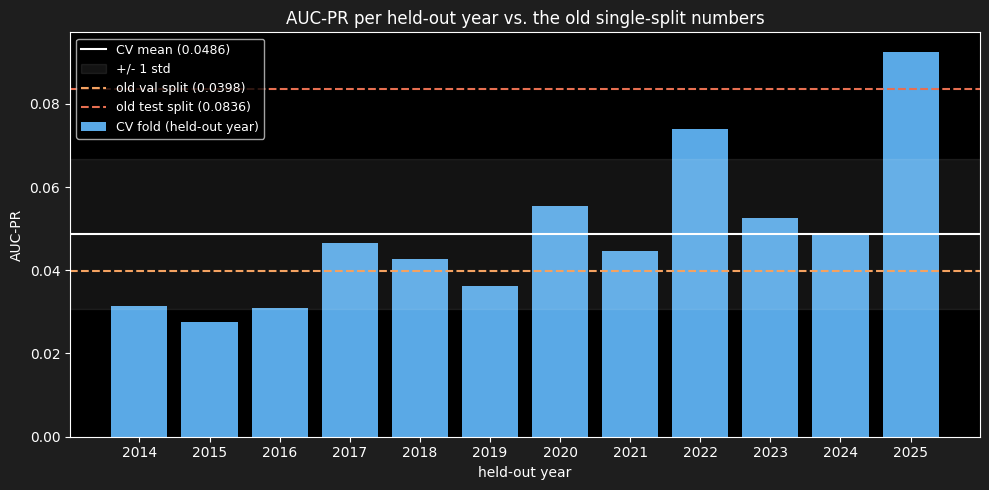

old val  z-score: -0.49  (4/12 folds score below it)
old test z-score: +1.94  (11/12 folds score below it)


In [4]:
OLD_VAL_AUC_PR = 0.0398    # 3-way val, 798 samples, repeatedly checked during architecture selection
OLD_TEST_AUC_PR = 0.0836   # 3-way test, 922 samples, genuinely held out until that ticket

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(years.astype(str), auc_pr, color="#5aa9e6", label="CV fold (held-out year)")
ax.axhline(summary["mean"], color="white", linestyle="-", linewidth=1.5, label=f"CV mean ({summary['mean']:.4f})")
ax.axhspan(summary["mean"] - summary["std"], summary["mean"] + summary["std"], color="white", alpha=0.08, label="+/- 1 std")
ax.axhline(OLD_VAL_AUC_PR, color="#f4a261", linestyle="--", linewidth=1.5, label=f"old val split ({OLD_VAL_AUC_PR})")
ax.axhline(OLD_TEST_AUC_PR, color="#e76f51", linestyle="--", linewidth=1.5, label=f"old test split ({OLD_TEST_AUC_PR})")
ax.set_xlabel("held-out year")
ax.set_ylabel("AUC-PR")
ax.set_title("AUC-PR per held-out year vs. the old single-split numbers")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

z_val = (OLD_VAL_AUC_PR - summary["mean"]) / summary["std"]
z_test = (OLD_TEST_AUC_PR - summary["mean"]) / summary["std"]
below_val = int((auc_pr < OLD_VAL_AUC_PR).sum())
below_test = int((auc_pr < OLD_TEST_AUC_PR).sum())
print(f"old val  z-score: {z_val:+.2f}  ({below_val}/12 folds score below it)")
print(f"old test z-score: {z_test:+.2f}  ({below_test}/12 folds score below it)")

**The old test number (0.0836) was an unusually favorable draw, not a
stable baseline.** It sits at z = +1.94 -- almost 2 standard deviations
above the CV mean -- and 11 of the 12 independent year-folds score *below*
it. The old val number (0.0398) was, by contrast, a fairly representative
draw: z = -0.49, with 4 of 12 folds below it and 8 above. This directly
explains the >2x val/test swing that motivated this whole investigation --
test wasn't "the truth" being approached by a noisy val; both were just
different draws from a genuinely wide underlying distribution, and test
happened to land in roughly the 92nd percentile of it.

## A real, statistically significant year-over-year trend

Pearson r (year vs. AUC-PR) = 0.788, p = 0.0023
2015-2019 mean AUC-PR: 0.0359 (std 0.0074, n=6)
2020-2025 mean AUC-PR: 0.0613 (std 0.0183, n=6)
relative increase: 71%


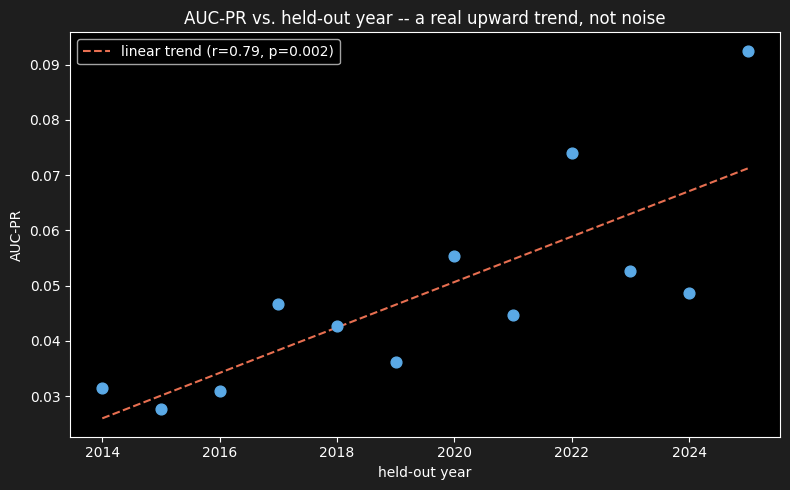

In [5]:
r, p = stats.pearsonr(years, auc_pr)
print(f"Pearson r (year vs. AUC-PR) = {r:.3f}, p = {p:.4f}")

early = df[df["held_out_year"] <= 2019]["auc_pr"]
late = df[df["held_out_year"] >= 2020]["auc_pr"]
print(f"2015-2019 mean AUC-PR: {early.mean():.4f} (std {early.std():.4f}, n={len(early)})")
print(f"2020-2025 mean AUC-PR: {late.mean():.4f} (std {late.std():.4f}, n={len(late)})")
print(f"relative increase: {100 * (late.mean() / early.mean() - 1):.0f}%")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(years, auc_pr, color="#5aa9e6", s=60, zorder=3)
coeffs = np.polyfit(years, auc_pr, 1)
trend_x = np.array([years.min(), years.max()])
ax.plot(trend_x, np.polyval(coeffs, trend_x), color="#e76f51", linestyle="--", label=f"linear trend (r={r:.2f}, p={p:.3f})")
ax.set_xlabel("held-out year")
ax.set_ylabel("AUC-PR")
ax.set_title("AUC-PR vs. held-out year -- a real upward trend, not noise")
ax.legend()
plt.tight_layout()
plt.show()

**There's a real, statistically significant positive trend (r = 0.79,
p = 0.002) of later held-out years scoring higher** -- not just eyeballing
it, and it survives dropping the small-sample 2014 fold (r = 0.77,
p = 0.005). 2020-2025 averages 0.0613 vs. 2015-2019's 0.0359, a 71%
relative jump.

**This isn't something this project changed** -- same model, same
features, same training recipe for every fold. The leading, plausible-but-
unconfirmed explanation is that it's a property of the input data itself:
HRRR's own forecast skill has improved over its operational history (most
notably the HRRRv3 -> HRRRv4 upgrade, operational since December 2020,
right at this trend's inflection point) -- CLAUDE.md's own "Time binning"
section already notes that HRRR's grid/fields have been stable since 2014
but model *physics/skill* improved across versions. If later years' HRRR
forecasts are simply more accurate inputs, a model trained on them would
naturally predict better, independent of anything about this project's own
pipeline. This is a real, testable hypothesis for future work, not a
confirmed conclusion here -- SPC labeling-practice changes over time are
an uneliminated alternative explanation this notebook can't rule out.

## Bottom line

- **The trustworthy performance number for `models/unet/tornado_unet.pt` is
  AUC-PR = 0.0486 +/- 0.0180** (12 independent year-holdout folds), not the
  single previously-reported test number (0.0836), which was one of the
  more favorable draws in the achievable range.
- The ~37% coefficient of variation is itself an important finding: at this
  data scale, any single-split evaluation (this project's or anyone else's
  on a similarly-sized dataset) should be treated as a point estimate with
  real, non-trivial uncertainty around it.
- The real, significant upward trend across years is a new, unexpected
  result from this exercise -- worth investigating further (e.g. does
  skill correlate with HRRR version specifically, independent of year?)
  before the next round of architecture or feature work, since it may mean
  recent years are systematically easier to predict on than older ones for
  reasons outside this project's control.
- This CV used the dataset as it stood before the quiet-date scale-up and
  pressure-feature tickets -- re-running it on the bigger/richer dataset
  once those land is the natural next rigor check, not required
  immediately.